In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv("/content/Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df["availability"].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [6]:
df["area_type"].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


<Axes: >

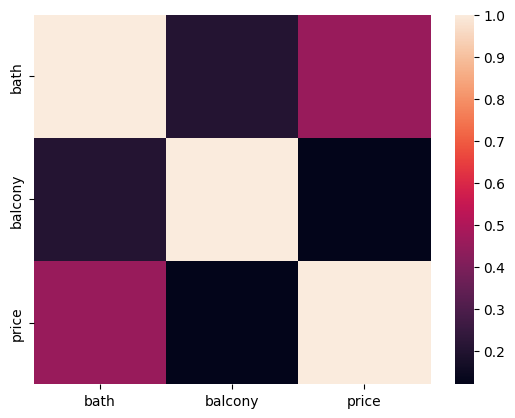

In [7]:
corr = df.select_dtypes("number").corr()
sns.heatmap(corr) #sns is a library heps us to create heatmaps

In [8]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [9]:
df1 = df.drop(columns = ['area_type','society','balcony','availability'])

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [11]:
df1.dropna(inplace = True)

In [12]:
df1.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [13]:
df1['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [14]:
df1['bedrooms'] = df1['size'].apply(lambda x: int(x.split(" ")[0]))

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 724.4+ KB


In [16]:
df1.head()

,location,size,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [17]:
df1 = df1.drop(columns = 'size')

In [18]:
df1['bedrooms'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [19]:
df1[df1.bedrooms>20]

,location,total_sqft,bath,price,bedrooms
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


In [20]:
df1['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [21]:
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [22]:
df1[~df1['total_sqft'].apply(is_float)].head(10)

,location,total_sqft,bath,price,bedrooms
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [23]:

def convert_sqft_to_num(x):
  if isinstance(x, float):
        return x
  tokens = x.split('-')
  if len(tokens) == 2:
      return (float(tokens[0])+float(tokens[1]))/2
  try:
      return float(x)
  except:
      return None

In [24]:
df4 = df1.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4.dropna(inplace=True)

df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 618.8+ KB


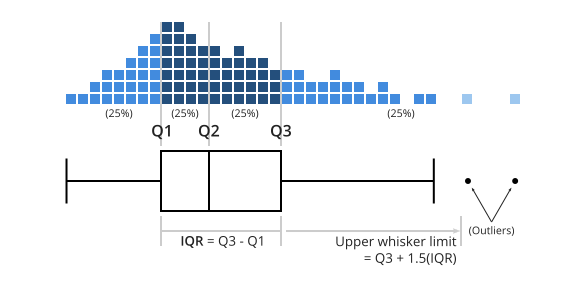

{'whiskers': [<matplotlib.lines.Line2D at 0x7c9829f02bd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9829f18ec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c982a231280>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9829f19580>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9829f19970>],
 'means': []}

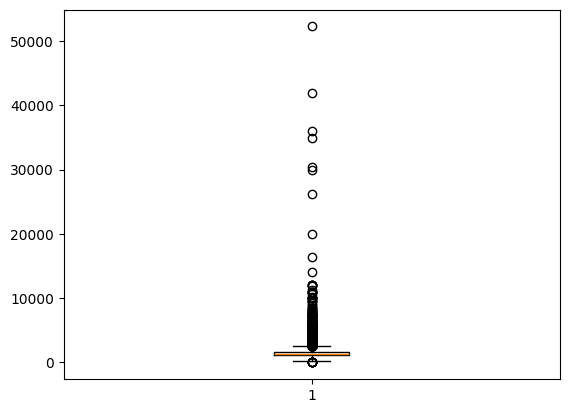

In [25]:
plt.boxplot(df4['total_sqft'])

In [26]:
df4['total_sqft'].describe()

,total_sqft
count,13200.000000
mean,1555.302783
std,1237.323445
min,1.000000
25%,1100.000000
50%,1275.000000
75%,1672.000000
max,52272.000000


In [27]:
low, high = df4['total_sqft'].quantile([0.1, 0.9])
mask_area = df4['total_sqft'].between(low, high)
df4 = df4[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x7c9829f3f650>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9827d9e660>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c9827d9e390>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9827d9ec30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9827d9eed0>],
 'means': []}

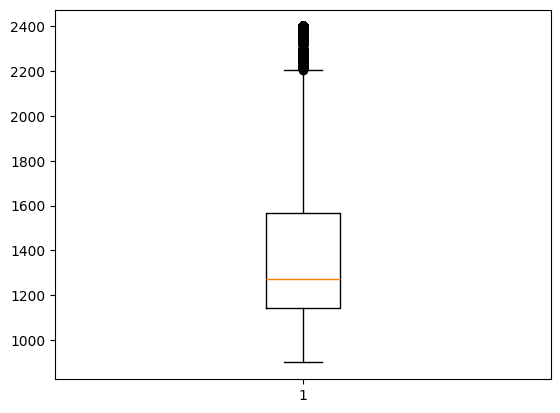

In [28]:
plt.boxplot(df4['total_sqft'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7c9827e48530>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9827e48b00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c9827e48200>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9827e49100>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9827e49400>],
 'means': []}

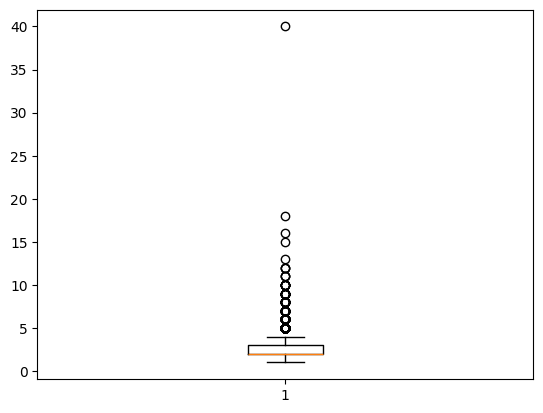

In [29]:
plt.boxplot(df4['bath'])

In [30]:
df4['bath'].describe()

,bath
count,10594.000000
mean,2.556069
std,1.088512
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


In [31]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


In [32]:
df4 = df4[df4['bath']<12]

In [33]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


{'whiskers': [<matplotlib.lines.Line2D at 0x7c9827ca1f70>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9827ca24b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c9827ca1cd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9827ca2a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9827ca2d20>],
 'means': []}

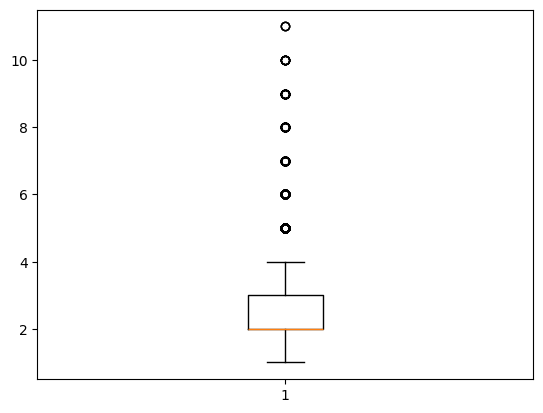

In [34]:
plt.boxplot(df4['bath'])

In [35]:
df4.head()

,location,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
5,Whitefield,1170.0,2.0,38.00,2


In [36]:
df4['price_per_sqft'] = df4['price']*100000/df4['total_sqft']

In [37]:
df4.head()

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,1170.0,2.0,38.00,2,3247.863248


In [38]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,10586.000000
mean,6244.315309
std,3698.326765
min,500.000000
25%,4206.709513
50%,5252.421226
75%,6761.335502
max,53150.000000


In [39]:
low, high = df4['price_per_sqft'].quantile([0.1, 0.9])
mask_area = df4['price_per_sqft'].between(low, high)
df4 = df4[mask_area]

In [40]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,8468.000000
mean,5525.927314
std,1399.739284
min,3500.408831
25%,4422.310757
50%,5252.421226
75%,6364.809866
max,9904.371585


{'whiskers': [<matplotlib.lines.Line2D at 0x7c9827ce3d40>,
 'caps': [<matplotlib.lines.Line2D at 0x7c9827d20320>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c9827ce3a70>],
 'medians': [<matplotlib.lines.Line2D at 0x7c9827d208f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c9827d20b30>],
 'means': []}

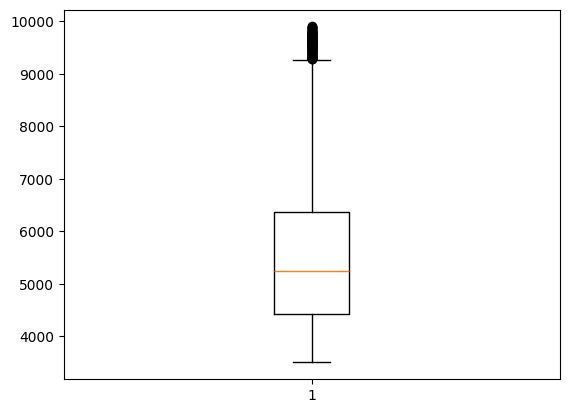

In [41]:
plt.boxplot(df4['price_per_sqft'])

In [42]:
df4.location = df4.location.apply(lambda x: x.strip())
location_stats = df4['location'].value_counts(ascending = False)
location_stats

,count
location,
Whitefield,355
Sarjapur Road,293
Kanakpura Road,205
Thanisandra,189
Electronic City,167
...,...
Madiwala,1
Jogupalya,1
Subhash Nagar,1


In [43]:
location_stats_less_than_10 = location_stats[location_stats<=10]
len(location_stats_less_than_10)

765

In [44]:
df4.location.nunique()

934

In [45]:
df4.location = df4.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df4.location.unique())

170

In [46]:
df4.head(10)

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
8,Marathahalli,1310.0,3.0,63.25,3,4828.244275
10,Whitefield,1800.0,2.0,70.00,3,3888.888889
12,7th Phase JP Nagar,1000.0,2.0,38.00,2,3800.000000
13,Gottigere,1100.0,2.0,40.00,2,3636.363636
14,Sarjapur,2250.0,3.0,148.00,3,6577.777778
15,Mysore Road,1175.0,2.0,73.50,2,6255.319149


In [47]:
df4 = df4.drop(columns = 'price_per_sqft')

In [48]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [49]:
from category_encoders import OneHotEncoder

In [50]:
x = df4.drop(['price'],axis = 'columns')

In [51]:
y = df4.price

In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 10)

In [53]:
model = make_pipeline(OneHotEncoder(), LinearRegression())
model.fit(x_train, y_train)

Pipeline(steps=[('onehotencoder', OneHotEncoder(cols=['location'])),
                ('linearregression', LinearRegression())])

In [54]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
mae

13.591634884069956

In [55]:
from sklearn.metrics import mean_absolute_percentage_error as error
mae = error(y_test, y_pred)
mae


0.17664696219476128

In [56]:

def predict_price(input_data: dict):
    input_df = pd.DataFrame([input_data])
    return model.predict(input_df)[0]
example_house = {
    'location': 'Whitefield',
    'total_sqft': 1200,
    'bath': 2,
    'bedrooms':2
}

print("Predicted Price:", predict_price(example_house))


Predicted Price: 62.99548916417295
